# Data Preparation

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, recall_score
from sklearn.ensemble import AdaBoostClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [30]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 
  
# data (as pandas dataframes) 
X = statlog_german_credit_data.data.features 
y = statlog_german_credit_data.data.targets 


In [31]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Attribute1   1000 non-null   str  
 1   Attribute2   1000 non-null   int64
 2   Attribute3   1000 non-null   str  
 3   Attribute4   1000 non-null   str  
 4   Attribute5   1000 non-null   int64
 5   Attribute6   1000 non-null   str  
 6   Attribute7   1000 non-null   str  
 7   Attribute8   1000 non-null   int64
 8   Attribute9   1000 non-null   str  
 9   Attribute10  1000 non-null   str  
 10  Attribute11  1000 non-null   int64
 11  Attribute12  1000 non-null   str  
 12  Attribute13  1000 non-null   int64
 13  Attribute14  1000 non-null   str  
 14  Attribute15  1000 non-null   str  
 15  Attribute16  1000 non-null   int64
 16  Attribute17  1000 non-null   str  
 17  Attribute18  1000 non-null   int64
 18  Attribute19  1000 non-null   str  
 19  Attribute20  1000 non-null   str  
dtypes: int64(7), str(13)

In [11]:
y.value_counts()

class
1        700
2        300
Name: count, dtype: int64

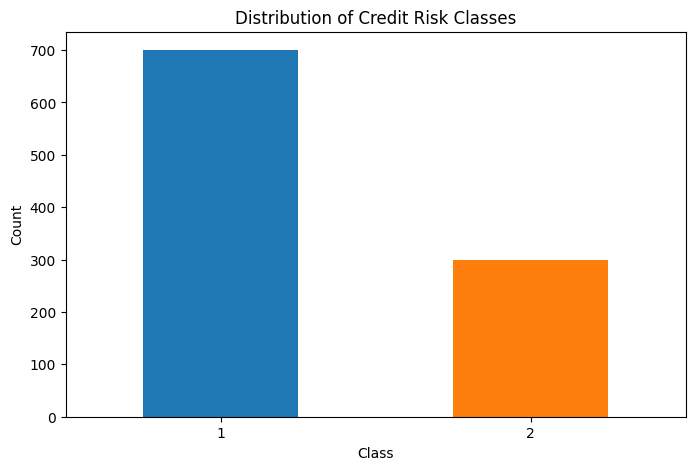

In [12]:
y['class'].value_counts().plot(kind='bar', figsize=(8, 5), color=['#1f77b4', '#ff7f0e'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Credit Risk Classes')
plt.xticks(rotation=0)
plt.show()

- Data is really unbalanced, but this won't be a problem for boosting algorithm

In [32]:
y['class'] = y['class'].map({1: 0, 2: 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Transform Categorical into numeric features

In [39]:
# cat_cols = X_train.select_dtypes(include=['str']).columns
# encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# X_train_encoded = encoder.fit_transform(X_train)
# X_test_encoded = encoder.transform(X_test)

from sklearn.compose import ColumnTransformer

cat_cols = X_train.select_dtypes(include=['object', 'str']).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)

    ],
    remainder='passthrough'
)

X_train_encoded_array = preprocessor.fit_transform(X_train)
X_test_encoded_array = preprocessor.transform(X_test)

encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
all_features = encoded_cat_cols + numeric_cols

X_train_encoded = pd.DataFrame(X_train_encoded_array, columns=all_features, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded_array, columns=all_features, index=X_test.index)

In [48]:
X_train_encoded.shape, X_test_encoded.shape

((800, 61), (200, 61))

### XGBModel

In [49]:
xgb = XGBClassifier()
xgb.fit(X_train_encoded, y_train.values.ravel())

#test set
y_pred_xgb = xgb.predict(X_test_encoded)
print("Test Set:\n",classification_report(y_test, y_pred_xgb))

y_proba_xgb = xgb.predict_proba(X_test_encoded)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))

Test Set:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85       141
           1       0.66      0.53      0.58        59

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200

ROC AUC Score: 0.8234162759947109


### AdaBoost Model

In [50]:
ada = AdaBoostClassifier()
ada.fit(X_train_encoded, y_train.values.ravel())


y_pred_ada = ada.predict(X_test_encoded)
print("Test Set:\n",classification_report(y_test, y_pred_ada))

y_proba_ada = ada.predict_proba(X_test_encoded)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_ada))

Test Set:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       141
           1       0.63      0.53      0.57        59

    accuracy                           0.77       200
   macro avg       0.72      0.70      0.71       200
weighted avg       0.76      0.77      0.76       200

ROC AUC Score: 0.8175862483471571


### LGBM Model

In [51]:
lgbm = LGBMClassifier(verbose=-1, random_state=42, is_unbalance=True)
lgbm.fit(X_train_encoded, y_train.values.ravel())

y_pred_lgbm = lgbm.predict(X_test_encoded)
print("Test Set:\n",classification_report(y_test, y_pred_lgbm))

y_proba_lgbm = lgbm.predict_proba(X_test_encoded)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_lgbm))

Test Set:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       141
           1       0.64      0.64      0.64        59

    accuracy                           0.79       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.79      0.79      0.79       200

ROC AUC Score: 0.8297872340425533


### CatBoost Model

In [52]:
catboost = CatBoostClassifier()
catboost.fit(X_train_encoded, y_train.values.ravel(), verbose=0)
y_pred_catboost = catboost.predict(X_test_encoded)
print("Test Set:\n",classification_report(y_test, y_pred_catboost))

y_proba_cat = catboost.predict_proba(X_test_encoded)[:, 1]
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_cat))

Test Set:
               precision    recall  f1-score   support

           0       0.82      0.94      0.88       141
           1       0.79      0.51      0.62        59

    accuracy                           0.81       200
   macro avg       0.81      0.73      0.75       200
weighted avg       0.81      0.81      0.80       200

ROC AUC Score: 0.8380815001803101


### Plot ROC-AUC Score

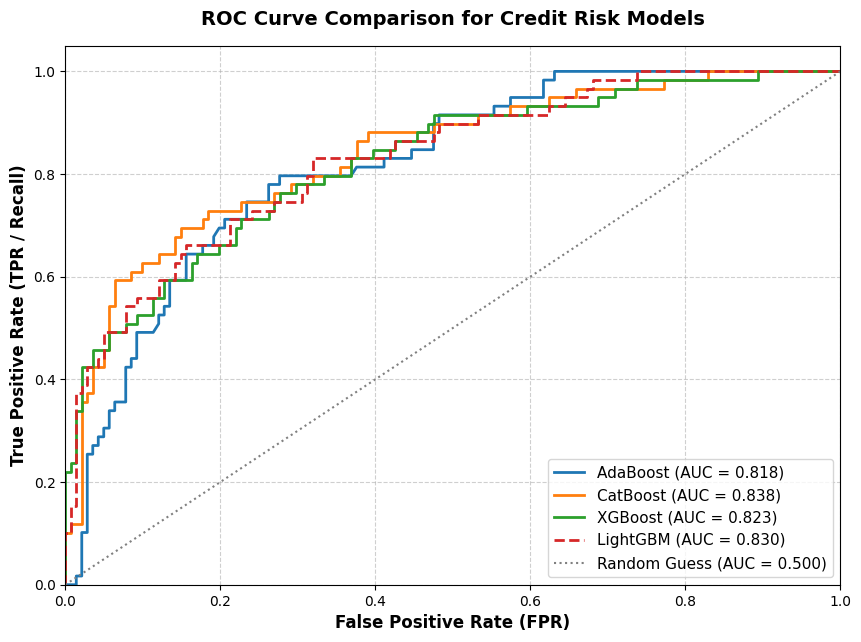

In [53]:
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_proba_ada)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_proba_cat)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgbm)

auc_ada = roc_auc_score(y_test, y_proba_ada)
auc_cat = roc_auc_score(y_test, y_proba_cat)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
auc_lgb = roc_auc_score(y_test, y_proba_lgbm)

# 5. Mulai proses pembuatan plot
plt.figure(figsize=(10, 7), facecolor='white')

# Plot kurva untuk masing-masing model
plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {auc_ada:.3f})', linewidth=2)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc_cat:.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', linewidth=2)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.3f})', linewidth=2, linestyle='--')

# Plot garis diagonal (Tebakan Acak / Baseline Minimum)
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Random Guess (AUC = 0.500)')

# Pengaturan Atribut Grafik (Sumbu, Judul, Legenda)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12, fontweight='bold')
plt.title('ROC Curve Comparison for Credit Risk Models', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

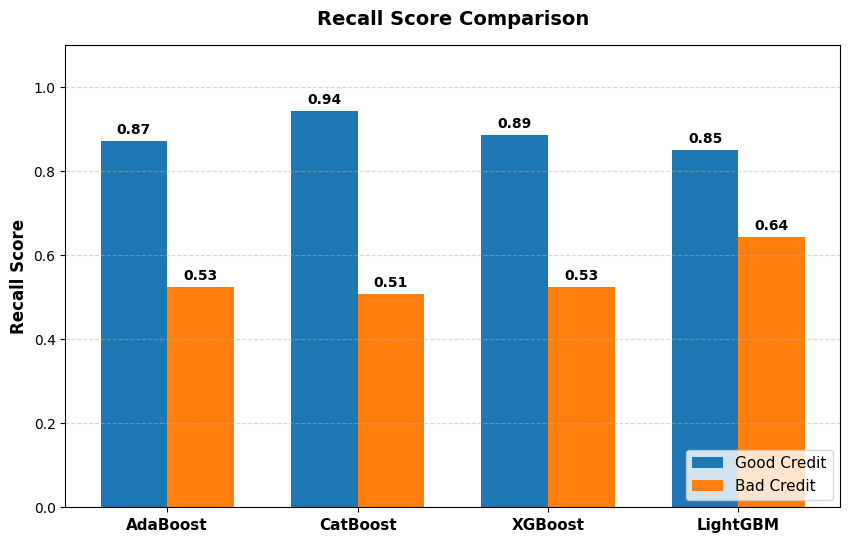

In [54]:
y_pred_ada = ada.predict(X_test_encoded)
y_pred_cat = catboost.predict(X_test_encoded)
y_pred_xgb = xgb.predict(X_test_encoded)
y_pred_lgb = lgbm.predict(X_test_encoded)

recall_0 = [
    recall_score(y_test, y_pred_ada, pos_label=0),
    recall_score(y_test, y_pred_cat, pos_label=0),
    recall_score(y_test, y_pred_xgb, pos_label=0),
    recall_score(y_test, y_pred_lgb, pos_label=0)
]

recall_1 = [
    recall_score(y_test, y_pred_ada, pos_label=1),
    recall_score(y_test, y_pred_cat, pos_label=1),
    recall_score(y_test, y_pred_xgb, pos_label=1),
    recall_score(y_test, y_pred_lgb, pos_label=1)
]


models = ['AdaBoost', 'CatBoost', 'XGBoost', 'LightGBM']
x = np.arange(len(models))  
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')


rects1 = ax.bar(x - width/2, recall_0, width, label='Good Credit', color='#1f77b4')
rects2 = ax.bar(x + width/2, recall_1, width, label='Bad Credit', color='#ff7f0e')


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Pengaturan atribut grafik (Label, Judul, Grid)
ax.set_ylabel('Recall Score', fontsize=12, fontweight='bold')
ax.set_title('Recall Score Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11, fontweight='bold')
ax.set_ylim([0, 1.1])  # Beri ruang di atas untuk label nilai
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)


# Tampilkan grafik
plt.show()

# Conclusion

- AdaBoost achieved AUC = 0.814 and Recall 41% for 'bad credit' class
- CatBoost achieved AUC = 0.825 and Recall 42% for 'bad credit' class
- XGBoost achieved AUC = 0.792 and Recall 51% for 'bad credit' class
- LightGBM achieved AUC = 0.794 and Recall 63% for 'bad credit' class

**LGBM** becomes the strongest model to use for its higher ability predicting 'bad' credit class